# Árvores de decisão

**Francisco A. Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Uma árvore de decisão é um modelo que toma decisões por meio de perguntas sucessivas.

Imagine a seguinte situação:

> Queremos decidir se uma pessoa deve levar um guarda-chuva.

Podemos construir regras como:

- está chovendo?
- o céu está nublado?
- há previsão de chuva?

Cada pergunta divide os dados em grupos menores.

Uma árvore possui:

- **raiz**: primeira pergunta;
- **nós internos**: perguntas intermediárias;
- **ramos**: caminhos possíveis;
- **folhas**: decisão final.

Considere uma regra muito simples:

```text
Temperatura < 20?
├── Sim  → Usar casaco
└── Não  → Não usar casaco
```

A árvore não utiliza uma fórmula única para todos os dados. Ela divide o espaço em regiões e atribui uma previsão a cada região.

Nessa aula vamos aprender sobre árvores de decisão, que podem ser usadas tanto para classificação quanto para regressão.

Inicialmente, vamos considerar as bibliotecas necessárias.

In [16]:
# Bibliotecas para cálculos e manipulação de dados
import numpy as np
import pandas as pd

# Biblioteca para gráficos
import matplotlib.pyplot as plt

# Geração de bases artificiais
from sklearn.datasets import make_moons, load_iris

# Divisão entre treinamento e teste
from sklearn.model_selection import train_test_split

# Modelos de árvore
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree,
    export_text
)

# Métricas de classificação
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Para tornar os resultados reproduzíveis
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Classificação

Vamos inicialmente criar uma base com duas classes e apenas dois atributos.

In [18]:
# Gera uma base artificial de classificação
X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=RANDOM_STATE
)
# Organiza os dados em um DataFrame apenas para visualização
class_df = pd.DataFrame(X,columns=["Atributo 1", "Atributo 2"])
class_df["Classe"] = y
class_df.head()

,Atributo 1,Atributo 2,Classe
0,-0.125245,0.552601,1
1,0.685084,-0.323315,1
2,0.769488,0.607225,0
3,0.428378,0.157977,1
4,0.075636,0.873185,0


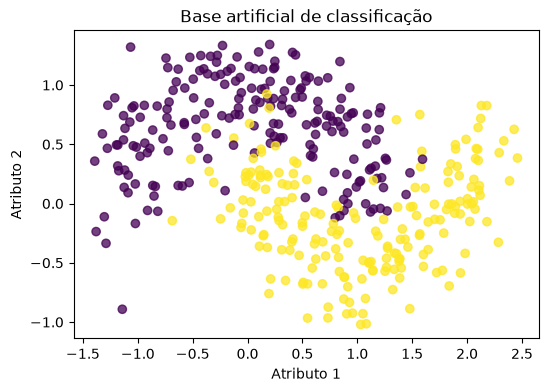

In [19]:
# Mostra os dados gerados
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0],X[:, 1],c=y,alpha=0.75)
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.title("Base artificial de classificação")
plt.show()

Selecionando os conjuntos de treinamento e teste. O argumento `stratify=y_class` preserva aproximadamente a proporção das classes.

In [21]:
# Separa 30% dos dados para teste e 70% para treinamento.
# stratify=y preserva, em cada conjunto, aproximadamente a mesma proporção de classes que existe na base completa.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

print("Número de exemplos para treinamento:", len(X_train))
print("Número de exemplos para teste:", len(X_test))

Número de exemplos para treinamento: 280
Número de exemplos para teste: 120


### Como a árvore escolhe as perguntas?

Até aqui vimos *o que* uma árvore faz (perguntas sucessivas que dividem os dados), mas ainda não vimos *como* ela decide qual pergunta fazer em cada nó.

A ideia central por trás da construção de uma árvore de decisão é o conceito de **impureza**. Um nó é considerado **puro** quando os exemplos que chegam até ele pertencem, em sua maioria ou totalmente, à mesma classe. Por outro lado, um nó é **impuro** quando contém exemplos de diferentes classes misturados.

Durante o treinamento, a árvore avalia várias divisões possíveis dos dados, por exemplo, perguntas como **“Atributo 1 < 0,5?”**. Para cada possibilidade, verifica o quanto essa divisão consegue separar melhor as classes. A árvore escolhe, então, a pergunta que produz a **maior redução de impureza**, isto é, aquela que gera grupos mais homogêneos em relação à classe dos exemplos.

Os dois critérios de impureza mais usados em classificação são:

**Índice de Gini**

$$
Gini(t) = 1 - \sum_{k=1}^{K} p_k^2
$$

**Entropia**

$$
Entropia(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)
$$

em que $p_k$ é a proporção de exemplos da classe $k$ no nó $t$, e $K$ é o número de classes. Em ambos os casos:

- o valor é **zero** quando o nó é puro (todos os exemplos de uma única classe);
- o valor é **máximo** quando as classes estão igualmente misturadas.

Os dois critérios costumam levar a árvores muito parecidas na prática, embora a entropia penalize a mistura de classes de forma ligeiramente diferente do Gini (a entropia usa logaritmo, o que a torna um pouco mais sensível a nós com distribuições bem desbalanceadas).

**Ganho de informação**

Para escolher a melhor pergunta em um nó $t$, a árvore compara a impureza antes e depois de cada divisão possível. Se uma divisão separa o nó $t$ em dois nós filhos $t_{esq}$ e $t_{dir}$, o ganho é:

$$
\text{Ganho} = I(t) - \left(\frac{n_{esq}}{n_t} I(t_{esq}) + \frac{n_{dir}}{n_t} I(t_{dir})\right)
$$

em que $I(\cdot)$ é o critério de impureza escolhido (Gini ou entropia), e $n_{esq}, n_{dir}, n_t$ são os números de exemplos em cada nó. A árvore escolhe, entre todas as perguntas possíveis, aquela que **maximiza o ganho de informação**, ou seja, a que produz os filhos mais puros possíveis.

Esse processo se repete recursivamente em cada novo nó, até que algum critério de parada seja atingido. Por exemplo, `max_depth` (profundidade máxima) ou `min_samples_leaf` (número mínimo de exemplos em uma folha). Esses dois parâmetros funcionam como um freio: sem eles, a árvore continuaria crescendo até que cada folha fosse perfeitamente pura, o que quase sempre leva a sobreajuste (como veremos adiante).

No `scikit-learn`, o critério é escolhido pelo argumento `criterion` do `DecisionTreeClassifier`, podendo ser `"gini"` (padrão) ou `"entropy"`.

Ajustando a árvore para classificação.

In [22]:
# Criamos uma árvore com profundidade máxima igual a max_depth.
# Esse limite ajuda a evitar uma árvore excessivamente complexa (veremos o efeito disso adiante).
# criterion="gini" é o critério de impureza apresentado acima (também é o padrão do scikit-learn; deixamos explícito aqui por clareza).
classifier = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# O modelo aprende as regras usando apenas o conjunto de treinamento.
classifier.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Fazendo previsões no conjunto de teste.

In [23]:
# Gera as classes previstas para o conjunto de teste.
y_pred = classifier.predict(X_test)

# Compara as classes previstas com as classes reais (proporcao de acertos).
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia no conjunto de teste: {accuracy:.3f}")

Acurácia no conjunto de teste: 0.917


A acurácia resume o desempenho em um único número, mas esconde **que tipo de erro** o modelo está cometendo. A **matriz de confusão** mostra, para cada classe real, quantos exemplos foram classificados corretamente e quantos foram confundidos com a outra classe.


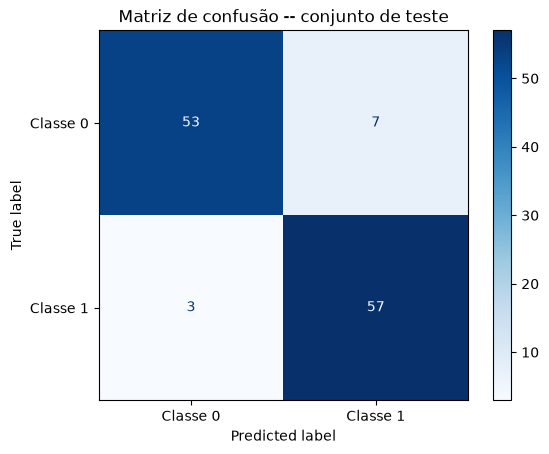

In [24]:
# Calcula a matriz de confusão: linhas = classe real, colunas = classe prevista.
matriz_confusao = confusion_matrix(y_test, y_pred)

# ConfusionMatrixDisplay monta a visualizacao a partir da matriz calculada acima.
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Classe 0", "Classe 1"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" mostra os valores como inteiros
plt.title("Matriz de confusão -- conjunto de teste")
plt.show()

Podemos visualizar a árvore obtida.

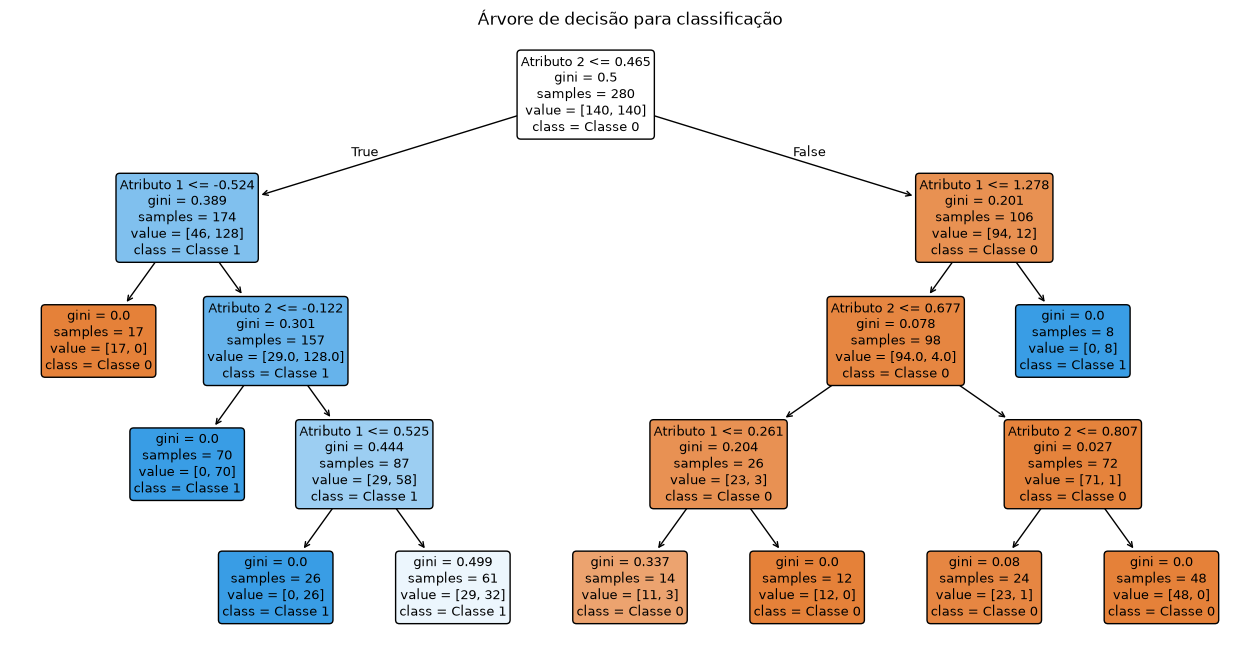

In [25]:
plt.figure(figsize=(16, 8))

# plot_tree desenha a arvore treinada: cada caixa e um no, com a condicao de divisao,
# a impureza (gini), o numero de exemplos e a classe majoritaria naquele no.
plot_tree(
    classifier,
    feature_names=["Atributo 1", "Atributo 2"],
    class_names=["Classe 0", "Classe 1"],
    filled=True,   # colore cada no de acordo com a classe predominante
    rounded=True,
    fontsize=9
)

plt.title("Árvore de decisão para classificação")
plt.show()

No formato texto.

In [26]:
# O comando export_text transforma a árvore em regras legíveis.
rules = export_text(
    classifier,
    feature_names=["Atributo 1", "Atributo 2"]
)

print(rules)

|--- Atributo 2 <= 0.47
|   |--- Atributo 1 <= -0.52
|   |   |--- class: 0
|   |--- Atributo 1 >  -0.52
|   |   |--- Atributo 2 <= -0.12
|   |   |   |--- class: 1
|   |   |--- Atributo 2 >  -0.12
|   |   |   |--- Atributo 1 <= 0.52
|   |   |   |   |--- class: 1
|   |   |   |--- Atributo 1 >  0.52
|   |   |   |   |--- class: 1
|--- Atributo 2 >  0.47
|   |--- Atributo 1 <= 1.28
|   |   |--- Atributo 2 <= 0.68
|   |   |   |--- Atributo 1 <= 0.26
|   |   |   |   |--- class: 0
|   |   |   |--- Atributo 1 >  0.26
|   |   |   |   |--- class: 0
|   |   |--- Atributo 2 >  0.68
|   |   |   |--- Atributo 2 <= 0.81
|   |   |   |   |--- class: 0
|   |   |   |--- Atributo 2 >  0.81
|   |   |   |   |--- class: 0
|   |--- Atributo 1 >  1.28
|   |   |--- class: 1



A árvore divide o plano em regiões retangulares. Cada região recebe uma classe.

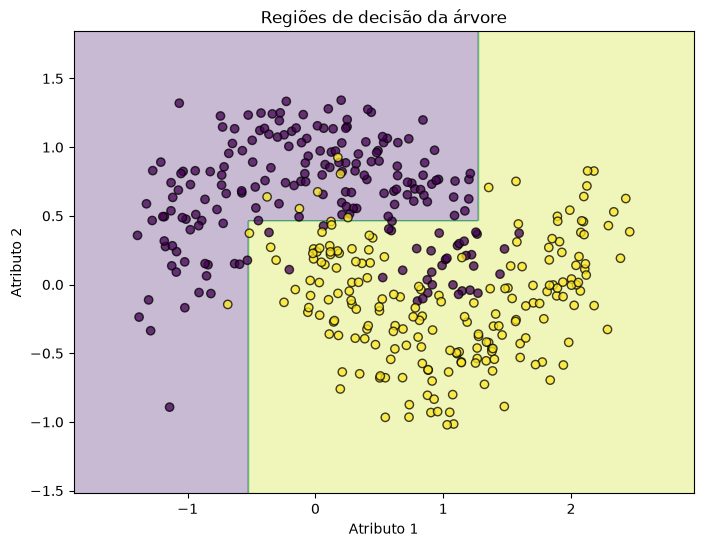

In [27]:
def plot_classification_regions(model, X, y, title):
    # Define os limites do gráfico.
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Cria uma grade de pontos.
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )

    # Faz previsões para todos os pontos da grade.
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx1.shape)

    # Mostra as regiões previstas.
    plt.figure(figsize=(8, 6))
    plt.contourf(
        xx1,
        xx2,
        predictions,
        alpha=0.3
    )

    # Mostra os dados reais.
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k",
        alpha=0.75
    )

    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.title(title)
    plt.show()


plot_classification_regions(
    classifier,
    X,
    y,
    "Regiões de decisão da árvore"
)

Vamos comparar árvores com profundidades diferentes.
- profundidade 1: árvore muito simples;
- profundidade 3: complexidade intermediária;
- profundidade 8: árvore mais complexa.

In [28]:
# Define as profundidades máximas que serão testadas.
depth_values = [1, 3, 8]

# Treina uma nova árvore para cada valor de profundidade.
for depth in depth_values:
    # Cria uma árvore de decisão limitando sua profundidade máxima.
    # Árvores rasas são mais simples, enquanto árvores mais profundas conseguem representar relações mais complexas nos dados.
    model_depth = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    # Treina a árvore utilizando os dados de treinamento.
    model_depth.fit(X_train,y_train)
    # Faz previsões para os próprios dados usados no treinamento.
    train_pred = model_depth.predict(X_train)
    # Faz previsões para dados que não foram usados no treinamento.
    test_pred = model_depth.predict(X_test)
    # Calcula a acurácia no conjunto de treinamento.
    train_accuracy = accuracy_score(y_train,train_pred)
    # Calcula a acurácia no conjunto de teste.
    test_accuracy = accuracy_score(y_test,test_pred)

    # Mostra os resultados para comparar o desempenho da árvore no treinamento e no teste.
    print(
        f"Profundidade = {depth} | "
        f"Acurácia treino = {train_accuracy:.3f} | "
        f"Acurácia teste = {test_accuracy:.3f}"
    )

Profundidade = 1 | Acurácia treino = 0.793 | Acurácia teste = 0.850
Profundidade = 3 | Acurácia treino = 0.882 | Acurácia teste = 0.917
Profundidade = 8 | Acurácia treino = 0.993 | Acurácia teste = 0.917


Pode ocorrer subajuste quando o modelo é simples demais para capturar os padrões presentes nos dados.
Os principais sinais de subajuste são:
- baixo desempenho no conjunto de treinamento;
- baixo desempenho no conjunto de teste.

Também pode ocorrer sobreajuste, quando o modelo aprende excessivamente os detalhes e os ruídos do conjunto de treinamento, mas apresenta baixa capacidade de generalização.

Os principais sinais de sobreajuste são:
- desempenho muito alto no conjunto de treinamento;
- desempenho significativamente inferior no conjunto de teste.

No caso das árvores de decisão, uma árvore muito profunda pode gerar folhas com poucas observações, tornando o modelo excessivamente sensível aos dados de treinamento e favorecendo a captura de ruídos.

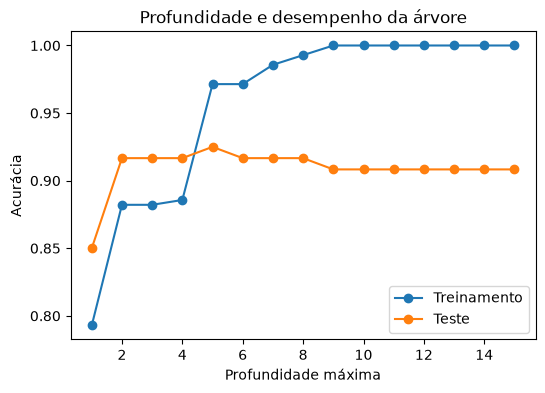

In [29]:
# Listas que irão armazenar as acurácias obtidas no conjunto de treinamento e no conjunto de teste.
train_scores = []
test_scores = []

# Define as profundidades máximas que serão avaliadas.
depth_range = range(1, 16)

# Treina uma nova árvore para cada profundidade máxima.
for depth in depth_range:
    # Cria a árvore com a profundidade máxima atual.
    model_depth = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    # Treina o modelo usando os dados de treinamento.
    model_depth.fit(X_train,y_train)

    # Calcula a acurácia nos dados de treinamento e armazena o resultado.
    train_scores.append(accuracy_score(y_train,model_depth.predict(X_train)))
    # Calcula a acurácia nos dados de teste e armazena o resultado.
    test_scores.append(accuracy_score(y_test,model_depth.predict(X_test)))

# Cria o gráfico para comparar o desempenho em função da profundidade da árvore.
plt.figure(figsize=(6, 4))
# A acurácia de treinamento tende a aumentar ou permanecer
# constante conforme a árvore se torna mais profunda.
plt.plot(list(depth_range),train_scores,marker="o",label="Treinamento")
# A acurácia de teste pode inicialmente aumentar, mas começar a diminuir quando ocorre sobreajuste.
plt.plot(list(depth_range),test_scores,marker="o",label="Teste")

plt.xlabel("Profundidade máxima")
plt.ylabel("Acurácia")
plt.title("Profundidade e desempenho da árvore")
plt.legend()
plt.show()

Vamos agora considerar uma base de dados.

In [30]:
# Para usar outra base de dados, basta alterar o caminho do arquivo abaixo.
# Exemplos:
# 'data/vertebralcolumn-3C.csv'
# 'data/winequality-red.csv'
# 'data/Vehicle.csv'
# 'data/iris.csv'

# Carrega a base de dados a partir de um arquivo CSV.
# header=0 indica que a primeira linha contém os nomes das colunas.
data = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv",header=0)
# Remove linhas que possuem algum valor ausente.
data = data.dropna(axis="rows")
# Consideramos que a última coluna contém a classe que desejamos prever.
classes = np.array(pd.unique(data[data.columns[-1]]),dtype=str)
# Todas as demais colunas são consideradas atributos.
features = data.columns[:-1]

# Obtém o número de observações e o número total de colunas.
nrow, ncol = data.shape

# Como a última coluna contém a classe,
# o número de atributos é igual ao número de colunas menos 1.
n_features = ncol - 1

print("Número de observações:", nrow)
print("Número de atributos:", n_features)
print("Número de classes:", len(classes))

# Mostra as primeiras 10 observações da base.
data.head(10)

Número de observações: 150
Número de atributos: 4
Número de classes: 3


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [31]:
# Converte o DataFrame para um array numpy, separando atributos (X) do rotulo (y),
# que por convencao esta na ultima coluna da base.
data = data.to_numpy()
nrow, ncol = data.shape
y = data[:, -1]
X = data[:, 0:ncol - 1]

Faz a classificação.

In [32]:
# Divide os dados em conjuntos de treinamento e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
# Cria uma árvore de decisão com profundidade máxima igual a max_depth.
model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
# Treina a árvore utilizando apenas o conjunto de treinamento.
model.fit(X_train, y_train)
# Utiliza a árvore treinada para prever as classes das observações do conjunto de teste.
y_pred = model.predict(X_test)
# Calcula a acurácia no conjunto de teste
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia na base Iris: {accuracy:.3f}")

Acurácia na base Iris: 0.967


A árvore obtida.

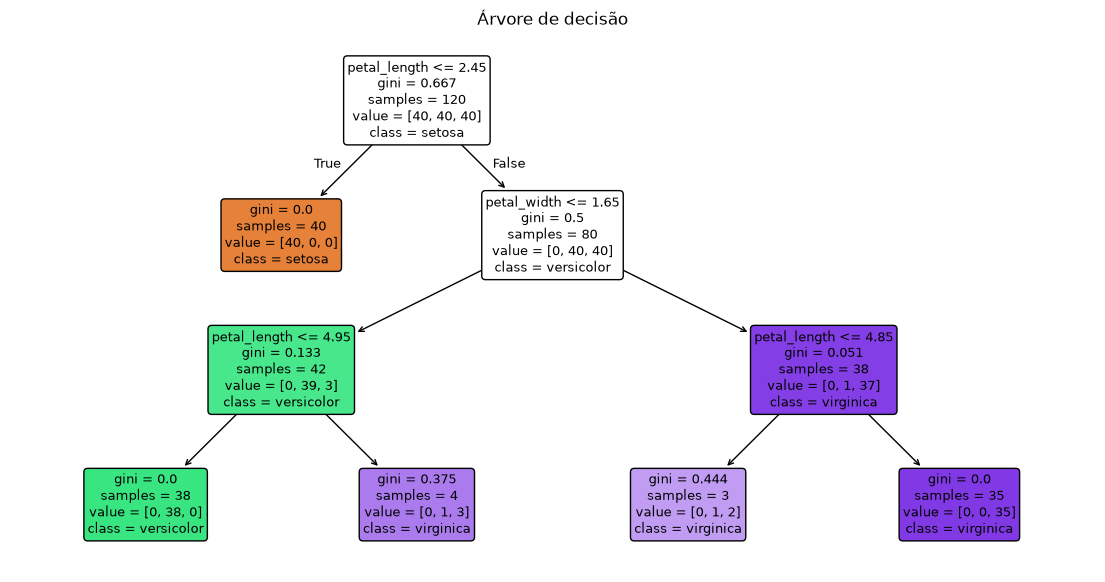

In [33]:
plt.figure(figsize=(14, 7))
# Mostra a arvore treinada na base real, com os nomes verdadeiros dos atributos e das classes.
plot_tree(model, feature_names=features, class_names=classes, filled=True, rounded=True, fontsize=9)
plt.title("Árvore de decisão")
plt.show()

### Importância dos atributos

Além de prever, uma árvore de decisão também informa **quais atributos foram mais úteis** para separar as classes. Cada vez que um atributo é usado em uma divisão, ele recebe crédito proporcional à redução de impureza que essa divisão proporcionou. Somando esse crédito ao longo de toda a árvore, obtemos a importância de cada atributo, disponível em `model.feature_importances_`.

Essas importâncias são sempre não-negativas e somam 1, sendo que podem ser lidas como "a fração da redução total de impureza que se deve a este atributo".


petal_length    0.579077
petal_width     0.420923
sepal_width     0.000000
sepal_length    0.000000
dtype: float64


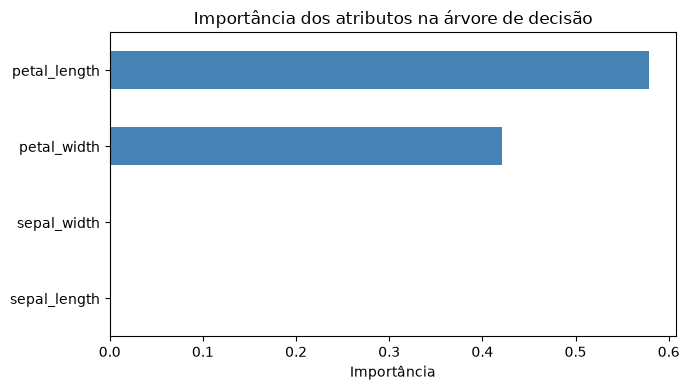

In [34]:
importancias = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importancias)

plt.figure(figsize=(7, 4))
importancias.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()  # atributo mais importante no topo
plt.xlabel("Importância")
plt.title("Importância dos atributos na árvore de decisão")
plt.tight_layout()
plt.show()

Embora esse cálculo seja simples, temos que ter cuidado na interpretação. A importância de um atributo depende da árvore específica que foi ajustada, de modo que pequenas mudanças nos dados de treinamento podem alterar bastante esses valores. Além disso, um atributo com importância baixa não significa necessariamente que ele seja irrelevante: se dois atributos carregam informação parecida, a árvore pode usar apenas um deles e ignorar o outro.


## Regressão

Na classificação, cada folha prevê uma classe. Já na regressão, cada folha prevê um valor numérico.

Por exemplo:
- preço médio de uma casa;
- temperatura;
- consumo de energia;
- tempo de entrega.

A árvore de regressão divide os dados em regiões e usa um valor médio em cada folha.

O princípio é o mesmo da classificação: reduzir a "impureza" a cada divisão. No entanto, agora a impureza é medida de outra forma, já que não há mais classes para comparar. O critério mais comum é o **erro quadrático médio (MSE)** dentro de cada nó:
$$
MSE(t) = \frac{1}{n_t}\sum_{i \in t} \left(y_i - \bar{y}_t\right)^2
$$
em que $\bar{y}_t$ é a média dos valores de $y$ dos exemplos que caem no nó $t$, e $n_t$ é o número desses exemplos. Esse é exatamente o mesmo tipo de erro (variância dos dados em torno da média) que aparece na regressão linear.

Assim como na classificação, a árvore testa possíveis divisões e escolhe a que mais reduz o MSE combinado dos dois nós filhos. A previsão em cada folha é simplesmente a **média** dos valores de treinamento que caíram naquela folha. Por isso a previsão final tem o formato de "degraus": dentro de uma mesma folha, a previsão é sempre a mesma, mudando apenas quando cruzamos para a folha vizinha.


Vamos criar um conjunto de dados artificiais para realizarmos a regressão.

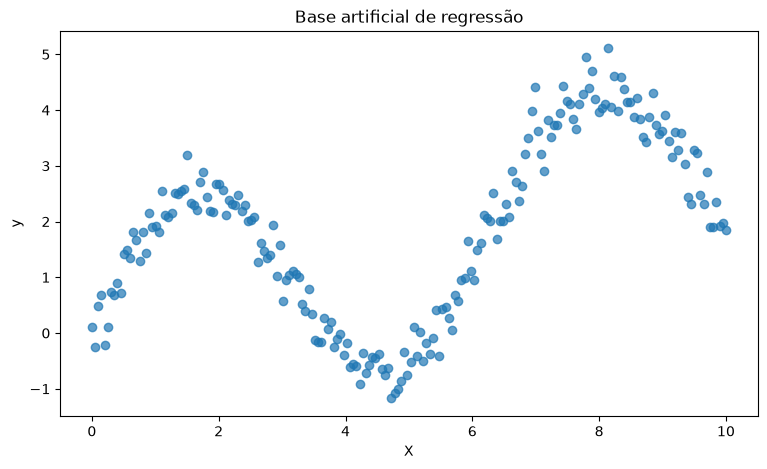

In [38]:
# Cria valores para a variável de entrada.
# O reshape(-1, 1) transforma o vetor em uma matriz com uma coluna,
X_reg = np.linspace(0, 10, 200).reshape(-1, 1)

# O ruído representa variações aleatórias.
rng = np.random.default_rng(RANDOM_STATE)
# Gera a variável resposta y a partir de uma relação não linear:
y_reg = (
    2 * np.sin(X_reg[:, 0])
    + 0.3 * X_reg[:, 0]
    + rng.normal(0, 0.35, size=len(X_reg))
)
# Visualiza os dados gerados.
plt.figure(figsize=(9, 5))
plt.scatter(X_reg[:, 0],y_reg,alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Base artificial de regressão")
plt.show()

Dividindo em treinamento e teste:

In [39]:
# Mesma logica do split de classificacao, mas sem 'stratify' (nao ha classes em regressao).
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE)
print("Treinamento:", X_train_reg.shape)
print("Teste:", X_test_reg.shape)

Treinamento: (160, 1)
Teste: (40, 1)


Ajustando o modelo.

In [40]:
# Cria uma árvore de decisão para regressão.
# max_depth=4: limita a profundidade máxima da árvore, controlando sua complexidade.
# min_samples_leaf=5: exige que cada folha tenha pelo menos 5 observações.
# Esses dois parâmetros funcionam como formas de regularização:
# evitam que a árvore crie divisões muito específicas e acabe se ajustando excessivamente ao ruído dos dados de treinamento.
regressor = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
# Treina a árvore utilizando o conjunto de treinamento.
# Durante o treinamento, a árvore procura sucessivamente
# as divisões dos valores de X que mais reduzem o erro dentro dos grupos resultantes.
regressor.fit(
    X_train_reg,
    y_train_reg
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

Mostrando o modelo ajustado.

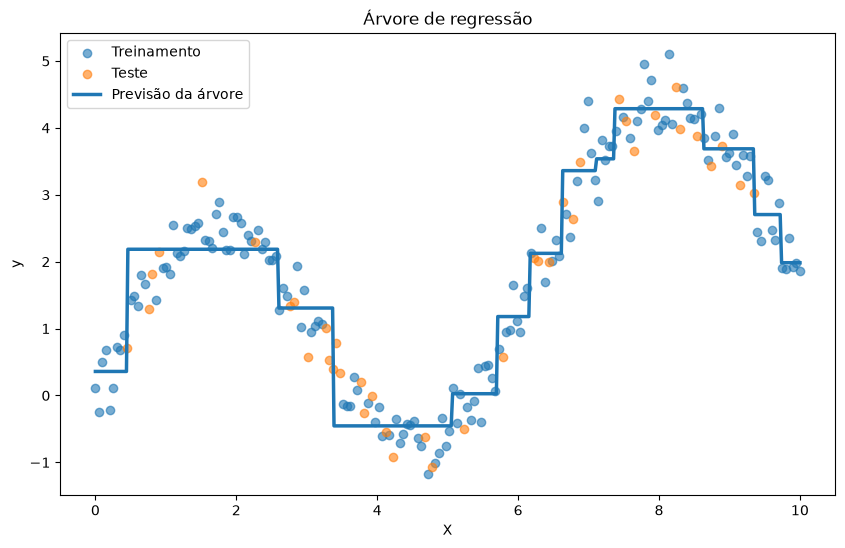

In [41]:
# Cria 500 valores igualmente espaçados entre o menor e o maior valor de X.
# Esses pontos serão usados apenas para visualizar a curva de previsão produzida pela árvore.
X_plot = np.linspace(
    X_reg.min(),
    X_reg.max(),
    500
).reshape(-1, 1)

# Calcula a previsão da árvore para cada ponto de X_plot.
# Como uma árvore de regressão atribui um valor constante
# a cada região do espaço, a curva prevista terá formato
# semelhante a uma função em degraus.
y_plot = regressor.predict(X_plot)

# Cria a figura.
plt.figure(figsize=(10, 6))
# Mostra os dados utilizados no treinamento da árvore.
plt.scatter(
    X_train_reg[:, 0],
    y_train_reg,
    alpha=0.6,
    label="Treinamento"
)

# Mostra os dados reservados para avaliar o modelo.
plt.scatter(
    X_test_reg[:, 0],
    y_test_reg,
    alpha=0.6,
    label="Teste"
)

# Desenha a função aprendida pela árvore de regressão.
plt.plot(
    X_plot[:, 0],
    y_plot,
    linewidth=2.5,
    label="Previsão da árvore"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Árvore de regressão")
plt.legend()
plt.show()

Podemos visualizar a árvore.

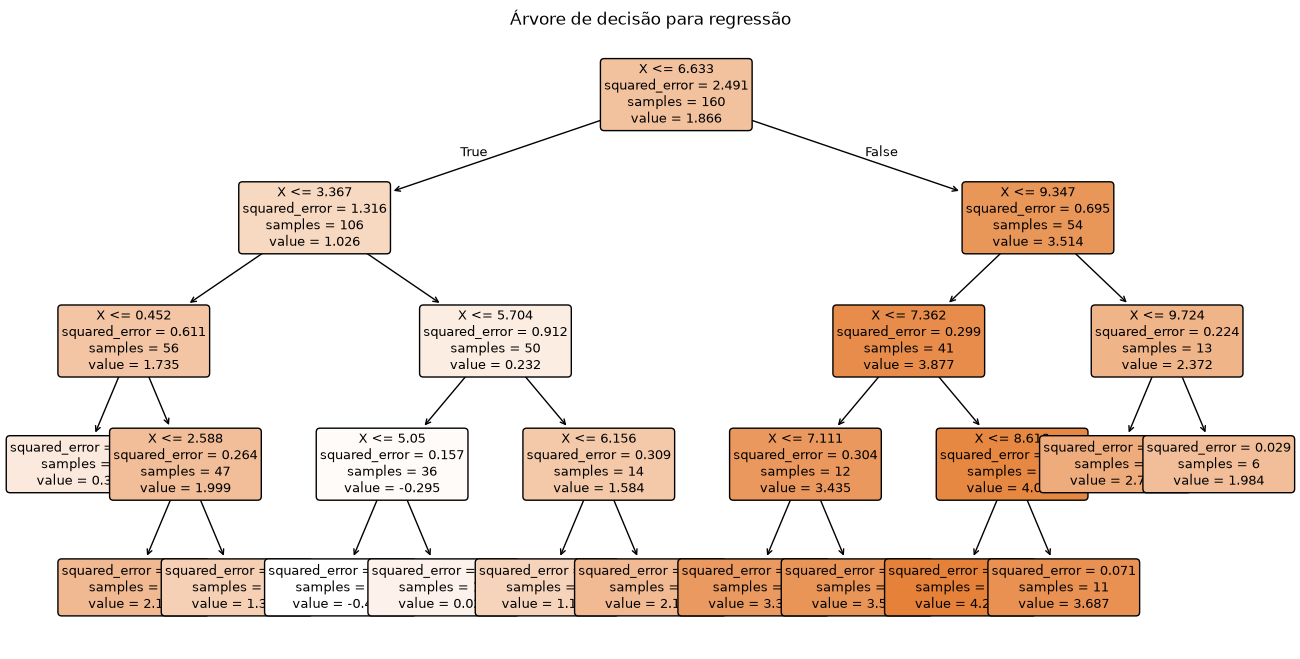

In [42]:
plt.figure(figsize=(16, 8))

# Assim como na classificacao, cada caixa e um no da arvore -- mas aqui, em vez de uma
# classe, cada folha mostra o valor medio (value) previsto para os exemplos que caem nela.
plot_tree(regressor, feature_names=["X"], filled=True, rounded=True, fontsize=9)
plt.title("Árvore de decisão para regressão")
plt.show()

A profundida da árvore influencia nos resultados, como vemos a seguir. 
- profundidade 1: poucas regiões e modelo muito simples;
- profundidade 3: captura melhor a tendência;
- profundidade 8: cria muitos degraus e pode capturar ruído.

Na regressão, assim como na classificação, aumentar a profundidade aumenta a flexibilidade do modelo.

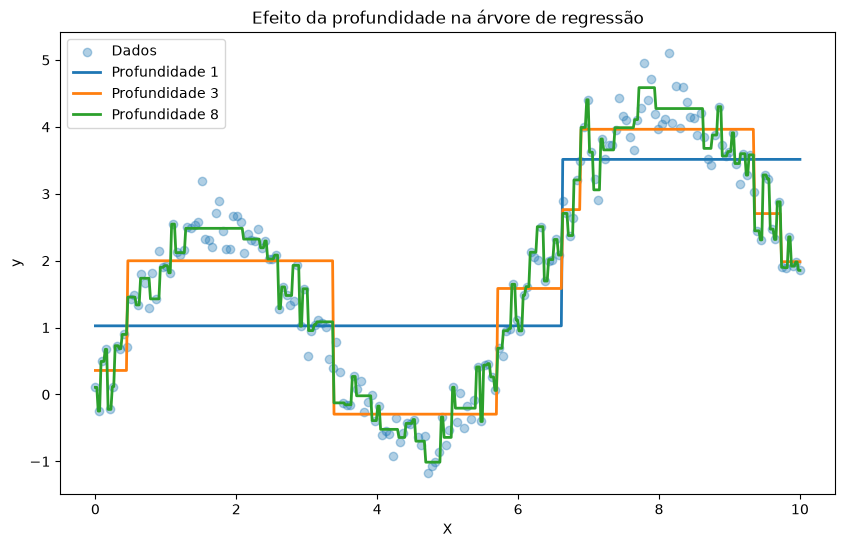

In [43]:
regression_depths = [1, 3, 8]

plt.figure(figsize=(10, 6))

# Mostra os dados originais como referencia visual.
plt.scatter(
    X_reg[:, 0],
    y_reg,
    alpha=0.35,
    label="Dados"
)

for depth in regression_depths:
    # Treina um regressor para cada profundidade e traca a curva de previsao correspondente.
    model_reg_depth = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    model_reg_depth.fit(
        X_train_reg,
        y_train_reg
    )

    predictions_plot = model_reg_depth.predict(X_plot)

    # Note o formato de "degraus": a previsao e constante dentro de cada folha da arvore.
    plt.plot(
        X_plot[:, 0],
        predictions_plot,
        linewidth=2,
        label=f"Profundidade {depth}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Efeito da profundidade na árvore de regressão")
plt.legend()
plt.show()

## Resumo

Vantagens em usar árvores de decisão:

- fácil interpretação;
- permite visualizar as regras;
- não exige padronização;
- funciona com relações não lineares;
- pode ser usada em classificação e regressão;
- permite estimar a importância dos atributos.

Limitações:
- árvores profundas podem sofrer sobreajuste;
- pequenas alterações nos dados podem mudar a árvore;
- a fronteira de decisão é formada por divisões retangulares;
- uma única árvore pode ser instável;
- previsões de regressão possuem formato de degraus.

## Exercícios de fixação

1 - Na base Vehicles.csv:
- ajuste uma árvore;
- calcule a acurácia;

Compare os critérios de divisão:

```python
criterion="gini"
```

```python
criterion="entropy"
```

Observe se a estrutura da árvore muda.

2 - Crie uma base com:
$$
y=x^2+\varepsilon
$$
Ajuste um modelo de regressão e compare árvores com diferentes profundidades.